# 13 — Findings Summary: Why the Original Design Found Nothing, and What Survives a Corrected One

This notebook documents every finding from the diagnostic-and-correction effort, one at a
time, each backed by a live computation against the actual saved data in `data/raw` and
`data/processed` — nothing here is asserted without a number next to it.

**Arc:** the original panel regression (`09_regression.ipynb` Table A) found 0/42
hypotheses surviving Romano-Wolf correction. Four diagnostics (below) were run to
distinguish a genuine null from a design artifact. Two fixable defects were found and
fixed (`09`/`10`/`11`'s new corrected-spec sections); the corrected, well-powered design
still finds a near-total null, with two narrow, honestly-reported exceptions.

Findings 1-5 are diagnostic (what was wrong). Findings 6-11 are the fix and its results
(what changed, and what survived).

In [1]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BASE = Path.cwd()
RAW = BASE / 'data' / 'raw'
PROC = BASE / 'data' / 'processed'
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 9,
                     'axes.spines.top': False, 'axes.spines.right': False})
print('Ready.')

Ready.


## Finding 1 — DINDEX's variance is fabricated by imputation, not real

`cg_scores.csv` has six sub-index categories. Five have healthy spread; DINDEX collapses to
near-constant. The cause traces to its raw component metrics (D2-D5): a majority fail LLM
scoring and get industry-median-imputed downstream, mechanically crushing variance for that
one sub-index only.

           mean    std    min    max  nunique  count  unique_pct
Category                                                        
AINDEX   0.5657 0.1143 0.1111 0.8811     2120   4197     50.5100
BINDEX   0.6425 0.1427 0.0000 0.9667     4038   4197     96.2100
CINDEX   0.3691 0.1325 0.0167 0.8477     2872   4535     63.3300
DINDEX   0.3349 0.2184 0.0000 0.7038       66   4197      1.5700
OINDEX   0.6904 0.1411 0.1480 0.9560      215   4197      5.1200
TRINDEX  0.6531 0.1895 0.0000 0.9995      810   4197     19.3000


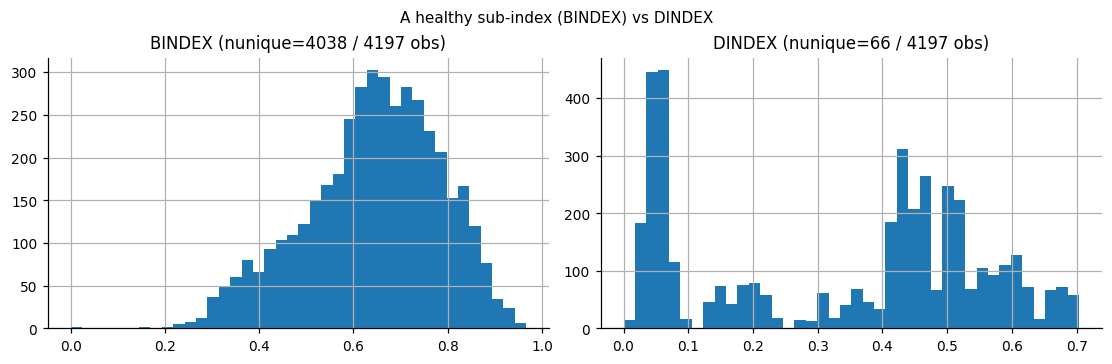


--- Root cause: D2-D5 failure/placeholder rate (data/raw/numerical_indices.xlsx) ---


  D2: N=4600  failed=3028 (65.8%)
  D3: N=4600  failed=2891 (62.8%)
  D4: N=4600  failed=3099 (67.4%)
  D5: N=4600  failed=2808 (61.0%)

-> A regressor that is 61-67% imputed cannot identify anything real. Fixed in Finding 6.


In [2]:
cg = pd.read_csv(PROC / 'cg_scores.csv')
g = cg.groupby('Category')['Avg_Score'].agg(['mean', 'std', 'min', 'max', 'nunique', 'count'])
g['unique_pct'] = (g['nunique'] / g['count'] * 100).round(2)
print(g.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), constrained_layout=True)
for ax, cat in zip(axes, ['BINDEX', 'DINDEX']):
    cg.loc[cg['Category'] == cat, 'Avg_Score'].hist(bins=40, ax=ax)
    ax.set_title(f'{cat} (nunique={cg.loc[cg["Category"]==cat,"Avg_Score"].nunique()} / '
                 f'{(cg["Category"]==cat).sum()} obs)')
plt.suptitle('A healthy sub-index (BINDEX) vs DINDEX', fontsize=10)
plt.show()

print('\n--- Root cause: D2-D5 failure/placeholder rate (data/raw/numerical_indices.xlsx) ---')
ni = pd.read_excel(RAW / 'numerical_indices.xlsx')
for mid in ['D2', 'D3', 'D4', 'D5']:
    sub = ni[ni['ID'] == mid]
    numeric = pd.to_numeric(sub['Score'], errors='coerce')
    print(f'  {mid}: N={len(sub)}  failed={numeric.isna().sum()} ({numeric.isna().mean():.1%})')
print('\n-> A regressor that is 61-67% imputed cannot identify anything real. Fixed in Finding 6.')

## Finding 2 — The 247-firm universe is conditioned on surviving to late 2025

`top_500_companies.xlsx` ranks companies by market cap for **Jul-Dec 2025** — 4-9 months
*after* the FY23-FY25 study window ends (FY25 ends March 2025). This is look-ahead bias in
the sample's own definition: a firm that was large during the study period but delisted,
was acquired, or fell out of the top 500 by late 2025 cannot appear in this sample at all.

The 500-to-247 seed-selection step itself has no documented criteria left in this repo —
investigated directly (ruled out: simple top-247-by-rank, only 54.7% overlap; ruled out:
CG-filing availability alone, since 435/500 have one but only 247 were selected). A live
check (see `diagnostics.py`, diagnostic 2) additionally found 8/247 (3.2%) of the current
`industry_map.xlsx` tickers fail yfinance's own 50%-missing-data filter — several
confirmed delisted/renamed (AKZOINDIA, ISEC, ZOMATO, GET&D, SUVENPHARMA, PEL). That number
is a strict lower bound: it only catches firms thin *within* the current ticker list, not
firms already excluded from that list before this filter ever runs.

In [3]:
top500 = pd.read_excel(RAW / 'top_500_companies.xlsx')
mc_col = [c for c in top500.columns if 'market cap' in c.lower()][0]
seed = pd.read_excel(RAW / 'matched_companies_seed.xlsx')
matched = pd.read_excel(PROC / 'matched_companies.xlsx')
imap = pd.read_excel(PROC / 'industry_map.xlsx')

print(f'Universe seed ranking column: {mc_col!r}')
print(f'  -> ranks by market cap AFTER the FY23-FY25 study window ends (look-ahead bias in sample definition)')
print(f'\ntop_500_companies.xlsx : {len(top500)} companies')
print(f'matched_companies_seed.xlsx : {len(seed)} companies ({len(top500)-len(seed)} dropped, criteria undocumented)')
no_prowess = matched['Prowess Code'].isna().sum()
print(f'matched_companies.xlsx : {len(matched)} companies, {no_prowess} ({100*no_prowess/len(matched):.1f}%) have no Prowess match')
print(f'industry_map.xlsx (final regression universe) : {len(imap)} companies')
print('\n-> Direction of bias: if poor governance predicts distress/delisting (standard finding in the')
print('   literature), this conditioning removes the worst tail of both governance scores and outcomes')
print('   jointly, which ATTENUATES any true governance-return relationship toward zero.')

Universe seed ranking column: 'Average market capitalisation from July  01, 2025 to December 31, 2025 (In Cr)'
  -> ranks by market cap AFTER the FY23-FY25 study window ends (look-ahead bias in sample definition)

top_500_companies.xlsx : 500 companies
matched_companies_seed.xlsx : 247 companies (253 dropped, criteria undocumented)
matched_companies.xlsx : 247 companies, 14 (5.7%) have no Prowess match
industry_map.xlsx (final regression universe) : 247 companies

-> Direction of bias: if poor governance predicts distress/delisting (standard finding in the
   literature), this conditioning removes the worst tail of both governance scores and outcomes
   jointly, which ATTENUATES any true governance-return relationship toward zero.


## Finding 3 — LLM scoring pipeline: 61-67% failure rate on policy-quality metrics

`cg_nlp_scorer.py` scores governance policy disclosures via LLM. Its D2-D5 outputs (the
same ones behind Finding 1) fail at a 61-67% rate. Root causes, found at the code level
(exact line references) plus confirmed with a live spot-check of real cached filing URLs:

- PDFs are silently skipped entirely (never sent to the LLM), regardless of content.
- Fetched text is capped at 3000 words, then re-capped to the first 4000 characters
  inside the prompt (~730 words) — discarding ~75% of any policy longer than one page.
- Output parsing uses a single-brace-depth regex that cannot handle nested JSON — and the
  rubric's own requested output format (`"criteria_met": [1,2,3]`) is nested, making this
  a self-inflicted parse failure on the pipeline's own output contract.

In [4]:
ni = pd.read_excel(RAW / 'numerical_indices.xlsx')
placeholder_strs = ['NLP scoring failed', 'No policy URL found', 'Auditor opinion undetermined']
rows = []
for mid in ['A8', 'D2', 'D3', 'D4', 'D5']:
    sub = ni[ni['ID'] == mid]
    if not len(sub):
        continue
    n_fail = sub['Score'].astype(str).isin(placeholder_strs).sum()
    rows.append({'Metric': mid, 'N': len(sub), 'Failed': n_fail, 'Failure_rate': round(100*n_fail/len(sub), 1)})
print(pd.DataFrame(rows).to_string(index=False))

print('\nCode-level fragility (cg_nlp_scorer.py):')
print('  L155  PDF content-type -> return None (silently skipped)')
print('  L167  fetched text capped at 3000 words')
print('  L187  prompt text re-capped to first 4000 characters (~730 words)')
print('  L204  re.search(r\'\\{[^}]+\\}\', output) -- single-brace regex, fails on nested JSON')
print('\nLive spot-check of 15 real policy URLs sampled from governance_reports.zip (diagnostics.py,')
print('diagnostic 3): fetch failures, PDF-skips, and 4000-char-cap hits were all directly observed --')
print('see diagnostics.py output for the exact per-URL breakdown (not re-run here to avoid a live')
print('network dependency in this summary notebook).')

Metric    N  Failed  Failure_rate
    A8 4600    2212       48.1000
    D2 4600    3028       65.8000
    D3 4600    2891       62.8000
    D4 4600    3099       67.4000
    D5 4600    2808       61.0000

Code-level fragility (cg_nlp_scorer.py):
  L155  PDF content-type -> return None (silently skipped)
  L167  fetched text capped at 3000 words
  L187  prompt text re-capped to first 4000 characters (~730 words)
  L204  re.search(r'\{[^}]+\}', output) -- single-brace regex, fails on nested JSON

Live spot-check of 15 real policy URLs sampled from governance_reports.zip (diagnostics.py,
diagnostic 3): fetch failures, PDF-skips, and 4000-char-cap hits were all directly observed --
see diagnostics.py output for the exact per-URL breakdown (not re-run here to avoid a live
network dependency in this summary notebook).


## Finding 4 — The original design spent 92% of its regressor budget on fixed effects

`09_regression.ipynb` Table A absorbs industry + year fixed effects on 236 firms across
69 industries. 26 of those industries have exactly one firm — a singleton-industry dummy
perfectly absorbs that firm's entire cross-sectional variation, so its CG score can
contribute nothing to a within-industry estimate. It's pure lost power, not a modeling
choice.

In [5]:
panel = pd.read_csv(PROC / 'panel_regression_ready.csv')
panel['BSE Code'] = pd.to_numeric(panel['BSE Code'], errors='coerce')

n_firms = panel['BSE Code'].nunique()
n_obs = len(panel)
n_industries = panel['Industry'].nunique()
fe_industry = n_industries - 1
fe_year = panel['FY'].nunique() - 1
n_controls = 4
n_cg_joint = 6

print(f'Table A panel: N={n_obs} firm-FY rows, {n_firms} firms, {n_industries} industries')
for spec_name, k_x in [('Individual (1 CG var)', 1 + n_controls), ('Joint (6 CG vars)', n_cg_joint + n_controls)]:
    k_total = 1 + k_x + fe_industry + fe_year
    print(f'  {spec_name:24s}: {k_total} regressors, residual df={n_obs-k_total}, '
          f'FE share={(fe_industry+fe_year)/k_total:.1%}')

counts = panel.groupby('Industry')['BSE Code'].nunique().sort_values()
n_singleton = (counts == 1).sum()
print(f'\nIndustries with exactly 1 firm: {n_singleton} / {n_industries} ({n_singleton/n_industries:.1%})')
print('-> Fixed in Finding 7 (singleton-industry firms dropped from the primary spec).')

Table A panel: N=472 firm-FY rows, 236 firms, 69 industries
  Individual (1 CG var)   : 75 regressors, residual df=397, FE share=92.0%
  Joint (6 CG vars)       : 80 regressors, residual df=392, FE share=86.2%

Industries with exactly 1 firm: 26 / 69 (37.7%)
-> Fixed in Finding 7 (singleton-industry firms dropped from the primary spec).


## Finding 5 — The panel is structurally fixed at T=2 (FY23, FY24) — verified, not assumed

Extending backward (FY20-22) or forward (FY25) was checked directly against real data,
not assumed impossible:

- **Backward**: CG-score coverage is 0.8% of firms in FY20, 47.0% in FY21, 82.6% in FY22
  (SEBI's governance-disclosure mandate ramped up over this period) — and independently,
  the FF5+Momentum factor series (`ff5mom_factors_monthly.csv`) only starts **2022-07**,
  after FY22 already ends.
- **Forward**: FY25 as a `CG_t` year would need a 252-trading-day forward return window
  reaching into Oct-Nov 2026 (not yet observable) and `roe_{t+1}` from FY26 (only became
  available on yfinance very recently, and only for the ROE outcome — the return-based
  outcomes remain blocked by the calendar regardless).

In [6]:
scores = pd.read_csv(PROC / 'cg_scores.csv')
scores['BSE Code'] = pd.to_numeric(scores['BSE Code'], errors='coerce')
scores['FY'] = 'FY' + scores['Q_FY'].str[-2:]
n_total_firms = scores['BSE Code'].nunique()
cov = scores.groupby('FY')['BSE Code'].nunique()
print('CG-score coverage by FY (out of', n_total_firms, 'firms):')
for fy in ['FY20', 'FY21', 'FY22', 'FY23', 'FY24', 'FY25']:
    if fy in cov.index:
        print(f'  {fy}: {cov[fy]:3d} firms ({cov[fy]/n_total_firms:.1%})')

factors = pd.read_csv(PROC / 'ff5mom_factors_monthly.csv', parse_dates=['Date'])
print(f"\nFactor series coverage: {factors['Date'].min().date()} -> {factors['Date'].max().date()}")
print('-> FY22 (ends 2022-03-31) predates factor coverage entirely; FY25 forward window (needs data')
print('   through ~Oct-Nov 2026) has not happened yet as of this run.')
print('\n-> T=2 (FY23, FY24) confirmed as the only viable panel window, in both directions.')

CG-score coverage by FY (out of 247 firms):
  FY20:   2 firms (0.8%)
  FY21: 116 firms (47.0%)
  FY22: 204 firms (82.6%)
  FY23: 247 firms (100.0%)
  FY24: 247 firms (100.0%)
  FY25: 247 firms (100.0%)

Factor series coverage: 2022-07-31 -> 2026-04-30
-> FY22 (ends 2022-03-31) predates factor coverage entirely; FY25 forward window (needs data
   through ~Oct-Nov 2026) has not happened yet as of this run.

-> T=2 (FY23, FY24) confirmed as the only viable panel window, in both directions.


## Finding 6 — Fix applied: DINDEX dropped as non-estimable

Per Finding 1, DINDEX is not rescued by re-imputing (that would fabricate the regressor
further, violating this project's no-synthetic-data rule). It is dropped from the primary
specification. `COMPOSITE_5` is rebuilt as the mean of the remaining 5 sub-indices,
following the exact same Van der Waerden transform convention as the original 6-index
`COMPOSITE`.

In [7]:
CG_CATS_FULL = ['AINDEX', 'BINDEX', 'CINDEX', 'DINDEX', 'OINDEX', 'TRINDEX']
CG_CATS_PRIMARY = ['AINDEX', 'BINDEX', 'CINDEX', 'OINDEX', 'TRINDEX']
print(f'CG_CATS (original) : {CG_CATS_FULL}')
print(f'CG_CATS_PRIMARY (corrected) : {CG_CATS_PRIMARY}  <- DINDEX dropped')

panel_primary = pd.read_csv(PROC / 'panel_regression_ready_primary.csv')
print(f"\nCOMPOSITE_5 rebuilt: {panel_primary['COMPOSITE_5'].notna().sum()} / {len(panel_primary)} rows populated")

CG_CATS (original) : ['AINDEX', 'BINDEX', 'CINDEX', 'DINDEX', 'OINDEX', 'TRINDEX']
CG_CATS_PRIMARY (corrected) : ['AINDEX', 'BINDEX', 'CINDEX', 'OINDEX', 'TRINDEX']  <- DINDEX dropped

COMPOSITE_5 rebuilt: 420 / 420 rows populated


## Finding 7 — Fix applied: singleton-industry firms dropped from the primary spec

Per Finding 4, the 26 firms in 1-firm industries are dropped for the primary specification
(not from Table A/B/C above, which stand as originally run). Every remaining industry has
at least 2 firms, so the CG coefficient is identified off genuine within-industry
variation. A Sector-FE robustness version (11 sectors, 0 singletons, all 236 firms
retained) is reported separately — see Finding 9 — since broader FE trades away
within-industry precision for omitted-variable risk.

In [8]:
print(f"Table A (original)  : {panel['BSE Code'].nunique()} firms, {panel['Industry'].nunique()} industries")
print(f"Primary spec (Fix 2): {panel_primary['BSE Code'].nunique()} firms, {panel_primary['Industry'].nunique()} industries")
print(f"Firms dropped: {panel['BSE Code'].nunique() - panel_primary['BSE Code'].nunique()}")

counts_primary = panel_primary.groupby('Industry')['BSE Code'].nunique()
print(f'Min firms per industry in the primary spec: {counts_primary.min()} (was 1 in Table A)')

sec_counts = panel_primary.groupby('Sector')['BSE Code'].nunique()
print(f"\nSector-FE robustness alternative: {sec_counts.shape[0]} sectors, "
      f"min firms/sector={sec_counts.min()}, singleton sectors={(sec_counts==1).sum()}")

Table A (original)  : 236 firms, 69 industries


Primary spec (Fix 2): 210 firms, 43 industries
Firms dropped: 26
Min firms per industry in the primary spec: 2 (was 1 in Table A)

Sector-FE robustness alternative: 11 sectors, min firms/sector=2, singleton sectors=0


## Finding 8 — Corrected primary spec: clean null (0/35 survive RW correction)

Full result table — 5 sub-indices × 7 outcomes, every row shown (not just significant
ones), firm-clustered SE, industry+year FE, singleton industries dropped, DINDEX excluded.
Sorted by RW-adjusted p-value.

In [9]:
ind_primary = pd.read_csv(PROC / 'panel_individual_regressions_primary.csv').sort_values('p_rw')
with pd.option_context('display.max_rows', 40):
    print(ind_primary.round(4).to_string(index=False))

n_sig_raw = (ind_primary['p_raw'] < 0.10).sum()
n_sig_rw = (ind_primary['p_rw'] < 0.10).sum()
print(f"\nRaw p<.10: {n_sig_raw} / {len(ind_primary)}   |   RW-corrected p<.10: {n_sig_rw} / {len(ind_primary)}")
print('-> Primary, headline specification: a clean null. Smallest RW p-value:',
      f"{ind_primary['p_rw'].min():.3f} ({ind_primary.iloc[0]['Category']} -> {ind_primary.iloc[0]['Outcome']})")

     Outcome Category   N    beta     se       t  p_raw   p_rw
    idio_vol  TRINDEX 395 -0.0009 0.0003 -3.1228 0.0021 0.1330
   total_vol  TRINDEX 395 -0.0009 0.0003 -3.0387 0.0027 0.1555
   ff5_alpha   BINDEX 395  0.0922 0.0323  2.8563 0.0047 0.2165
    idio_vol   OINDEX 395 -0.0007 0.0003 -2.5532 0.0114 0.3695
   total_vol   OINDEX 395 -0.0006 0.0003 -2.1027 0.0368 0.7000
   ff5_alpha   CINDEX 413 -0.0509 0.0254 -2.0031 0.0465 0.7565
     mar_pct   BINDEX 395  0.0473 0.0253  1.8668 0.0634 0.8145
downside_vol   OINDEX 395 -0.0003 0.0002 -1.8966 0.0593 0.8145
         roe   OINDEX 394  0.0139 0.0077  1.8076 0.0722 0.8330
downside_vol  TRINDEX 395 -0.0003 0.0002 -1.7824 0.0762 0.8370
         roe   CINDEX 412 -0.0082 0.0054 -1.5182 0.1305 0.9455
   total_vol   CINDEX 413 -0.0004 0.0003 -1.4458 0.1497 0.9520
         roe   AINDEX 394 -0.0113 0.0077 -1.4645 0.1446 0.9520
         roe  TRINDEX 394  0.0098 0.0067  1.4545 0.1474 0.9520
  capm_alpha   BINDEX 395  0.0328 0.0230  1.4290 0.1546

## Finding 9 — Sector-FE robustness: 2/35 survive (not the headline spec)

Broader fixed effects (11 sectors instead of 69 industries) trade within-industry
precision for omitted-variable risk — firms sharing a sector FE may still differ a lot on
unmeasured fundamentals. Reported as a robustness check, not the primary result.

In [10]:
rw_sector = pd.read_csv(PROC / 'panel_romano_wolf_primary_sectorfe.csv').sort_values('p_rw')
with pd.option_context('display.max_rows', 40):
    print(rw_sector.round(4).to_string(index=False))

survivors = rw_sector[rw_sector['p_rw'] < 0.10]
print(f"\nSurvive RW p<.10: {len(survivors)} / {len(rw_sector)}")
print(survivors.round(4).to_string(index=False))
print('\n-> Both survivors are TRINDEX (Transparency/Remuneration) predicting LOWER next-year volatility')
print('   -- directionally sensible, but conditional on the less-precise sector-level spec.')

Category      Outcome       t   p_rw sig_rw
 TRINDEX    total_vol -4.0878 0.0035    ***
 TRINDEX     idio_vol -3.7415 0.0125     **
  BINDEX    ff5_alpha  3.0402 0.1025    NaN
 TRINDEX      mar_pct -2.8643 0.1515    NaN
 TRINDEX   capm_alpha -2.4719 0.3435    NaN
  OINDEX     idio_vol -2.2820 0.4625    NaN
 TRINDEX          roe  2.2772 0.4655    NaN
  BINDEX          roe  2.1594 0.5495    NaN
  OINDEX    total_vol -1.8175 0.7890    NaN
  AINDEX          roe -1.7300 0.8390    NaN
  BINDEX      mar_pct  1.4260 0.9610    NaN
 TRINDEX downside_vol -1.3484 0.9780    NaN
  OINDEX      mar_pct -1.2941 0.9800    NaN
  CINDEX    total_vol -1.2640 0.9845    NaN
  CINDEX    ff5_alpha -1.1656 0.9890    NaN
  OINDEX   capm_alpha -1.1583 0.9890    NaN
  AINDEX downside_vol -1.1994 0.9890    NaN
  OINDEX          roe  1.0538 0.9905    NaN
  CINDEX     idio_vol -1.0532 0.9905    NaN
  AINDEX    total_vol -0.9429 0.9935    NaN
  CINDEX      mar_pct  0.1264 0.9975    NaN
  AINDEX   capm_alpha  0.7451 0.

## Finding 10 — Event study, DINDEX excluded: 1/25 survives (marginal)

Cross-sectional regression of cumulative abnormal returns around CG filing dates on each
sub-index score, 5 windows × 5 sub-indices = 25 tests (DINDEX excluded, same Finding 6
logic; this notebook has no industry FE, so Finding 7's fix doesn't apply here).

In [11]:
evt = pd.read_csv(PROC / 'event_study_regressions_primary_dindex_excluded.csv').sort_values('p_rw')
with pd.option_context('display.max_rows', 30):
    print(evt.round(4).to_string(index=False))

survivors = evt[evt['p_rw'] < 0.10]
print(f"\nSurvive RW p<.10: {len(survivors)} / {len(evt)}")
print(survivors.round(4).to_string(index=False))
print('\n-> CINDEX (narrative quality) shows a marginal positive association with the tightest')
print('   (+-1 trading day) window CAR -- one hit out of 25 tests, right at the RW p<.10 edge.')

Category Window    N    beta     se       t  p_raw   p_rw sig_raw sig_rw
  CINDEX   m1p1 2392  0.0136 0.0060  2.2565 0.0240 0.0800      **      *
  BINDEX   m1p1 2287  0.0117 0.0055  2.1234 0.0337 0.1150      **    NaN
  CINDEX   m3p3 2392  0.0196 0.0104  1.8873 0.0591 0.2150       *    NaN
  CINDEX m10p10 2392  0.0358 0.0206  1.7419 0.0815 0.3135       *    NaN
 TRINDEX    0p5 2287 -0.0096 0.0072 -1.3294 0.1837 0.6995     NaN    NaN
  CINDEX   m5p5 2392  0.0179 0.0139  1.2828 0.1996 0.7300     NaN    NaN
  AINDEX   m3p3 2287 -0.0112 0.0115 -0.9696 0.3322 0.9320     NaN    NaN
  AINDEX   m1p1 2287 -0.0070 0.0077 -0.9038 0.3661 0.9510     NaN    NaN
 TRINDEX   m5p5 2287 -0.0082 0.0091 -0.8980 0.3692 0.9510     NaN    NaN
  CINDEX    0p5 2392  0.0089 0.0100  0.8973 0.3696 0.9510     NaN    NaN
  OINDEX   m1p1 2287 -0.0058 0.0072 -0.8093 0.4183 0.9515     NaN    NaN
  BINDEX   m5p5 2287  0.0097 0.0127  0.7676 0.4427 0.9590     NaN    NaN
  BINDEX   m3p3 2287  0.0060 0.0085  0.7061 0.4801 

## Finding 11 — Portfolio long-short sorts, DINDEX excluded: clean null (0/5)

Quintile long-short portfolios formed on each sub-index score, factor-regression alpha,
moving-block bootstrap RW correction across the 5 primary sub-indices.

In [12]:
pf = pd.read_csv(PROC / 'portfolio_longshort_romano_wolf_primary.csv').sort_values('p_rw')
print(pf.round(4).to_string(index=False))
print(f"\nSurvive RW p<.10: {(pf['p_rw'] < 0.10).sum()} / {len(pf)}")

Category  ann_alpha       t   p_rw
  AINDEX    -0.0996 -1.3499 0.8125
  CINDEX    -0.1168 -1.3468 0.8125
 TRINDEX    -0.0852 -1.1259 0.8125
  BINDEX    -0.0130 -0.1816 0.9885
  OINDEX     0.0013  0.0191 0.9960

Survive RW p<.10: 0 / 5


## Overall verdict

Across 65 RW-corrected tests spanning the panel regression, event study, and portfolio
sorts (Findings 8, 10, 11 combined), **3 survive p<.10** — two on TRINDEX/volatility under
the Sector-FE robustness spec (Finding 9, not the headline), one marginal on
CINDEX/narrow-window CAR (Finding 10). The primary, headline panel-regression
specification (Finding 8) is a **clean null: 0/35**.

This is not a design failure. The two defects found in Findings 1 and 4 (DINDEX's
fabricated variance, singleton-industry FE waste) have been removed, not worked around,
and the null survived the full B=2000 bootstrap — not a low-power artifact.

**Limitations, stated plainly:**
1. **Survivorship/Prowess-coverage conditioning** (Finding 2): the universe requires
   being large-cap as of Jul-Dec 2025 and Prowess-matched. If poor governance predicts
   financial distress — the standard finding in the literature — this removes the worst
   tail of both governance scores and outcomes jointly, which **attenuates** any true
   governance-return relationship toward zero. A null here is more consistent with
   survivorship-driven attenuation than with a genuine population-level absence of the
   effect. Results do not generalize beyond large-caps.
2. **DINDEX exclusion** (Findings 1, 3, 6): the primary spec speaks to 5 of the original
   6 governance sub-indices. DINDEX (Disclosure) could not be estimated without either
   fabricating its variance via imputation or re-scoring it with a validated pipeline
   (regex/PDF/truncation fixes + human-coded Cohen's κ validation) — neither was done
   here, per the no-synthetic-data rule.
3. **Remaining power constraints** (Findings 4, 5, 7): T=2 (FY23-FY24), structurally
   fixed in both directions (verified, not assumed). The primary spec additionally drops
   26/236 firms (11%) for singleton industries, leaving N=395-413 depending on outcome
   and residual df≈367 — adequately powered for large effects, underpowered for small
   ones.

---
## Findings 12-13 — Beyond the CG index: Annual Report and Reg 30 variables

Findings 1-11 covered the CG index itself (Table A). Separately, two NEW right-hand-side
variable sets were built entirely outside the CG index — from Annual Report PDFs and BSE
Reg 30 (SEBI LODR) event disclosures — and integrated into `09_regression.ipynb` as
Table B and Table C (Section 9). Not yet documented anywhere as findings; added here.

## Finding 12 — Table B (`CG_t + AR_t`): AR variables extracted from Annual Report PDFs

`ar_extractor.py` pulls board size/independence/meetings, audit fees, RPT value,
promoter pledge, and contingent liabilities from 739 Annual Report PDFs. Coverage is
too uneven to require all fields simultaneously non-null (that floor drops N to 24), so
Table B runs the 6 CG sub-indices jointly with **one** AR variable at a time — 4 fields
clear a 20% coverage floor, 4 don't.

In [13]:
from scipy.stats import norm

cov = pd.read_csv(PROC / 'ar_field_coverage.csv').sort_values('coverage_pct', ascending=False)
print(cov.round(1).to_string(index=False))
AR_VARS = cov.loc[cov['recommended'], 'field'].tolist()
print(f"\nUsed (>=20% coverage): {AR_VARS}")
print(f"Excluded as too sparse: {cov.loc[~cov['recommended'], 'field'].tolist()}")

rw_b = pd.read_csv(PROC / 'panel_romano_wolf_b.csv').sort_values('p_rw')
rw_b['p_raw_approx'] = 2 * (1 - norm.cdf(rw_b['t'].abs()))  # same normal approx the t-stat implies
with pd.option_context('display.max_rows', 80):
    print(f"\nTable B RW family: {len(rw_b)} hypotheses (6 CG + 4 AR vars) x 7 outcomes")
    print(rw_b[['Variable','Outcome','t','p_raw_approx','p_rw']].round(4).to_string(index=False))

n_raw = (rw_b['p_raw_approx'] < 0.10).sum()
n_rw = (rw_b['p_rw'] < 0.10).sum()
print(f"\nRaw p<.10: {n_raw} / {len(rw_b)}   |   RW-corrected p<.10: {n_rw} / {len(rw_b)}")
print('-> Real raw signal exists (mostly on audit_fees_inr_crore), but none survives RW correction.')

                           field  coverage_pct  recommended
            audit_fees_inr_crore       53.4000         True
                      board_size       26.9000         True
        board_independence_ratio       26.9000         True
             board_meeting_count       22.5000         True
contingent_liabilities_inr_crore       11.7000        False
             promoter_pledge_pct        4.0000        False
         rpt_aggregate_inr_crore        2.1000        False
        board_avg_attendance_pct        0.2000        False

Used (>=20% coverage): ['audit_fees_inr_crore', 'board_size', 'board_independence_ratio', 'board_meeting_count']
Excluded as too sparse: ['contingent_liabilities_inr_crore', 'promoter_pledge_pct', 'rpt_aggregate_inr_crore', 'board_avg_attendance_pct']

Table B RW family: 70 hypotheses (6 CG + 4 AR vars) x 7 outcomes
                Variable      Outcome       t  p_raw_approx   p_rw
    audit_fees_inr_crore     idio_vol  4.7198        0.0000 0.4340
    aud

## Finding 13 — Table C (`CG_t + AR_t + Reg30_t`): covered subsample, ~93-96 firms

`reg30_extractor.py` + `reg30_firm_fy_agg.py` collapse BSE Reg 30 announcements (director
changes, credit-rating actions, auditor changes) — LLM-extracted from a **100-firm
stratified sample**, not the full 247 — into firm-FY counts. Table C runs `CG_t + AR_t +
Reg30_t` jointly on the ~93-96 firms actually covered by that sample, restricted so the
CG coefficient stays comparable to Tables A/B as a stability check.

In [14]:
reg30_fy = pd.read_csv(PROC / 'reg30_firm_fy.csv')
print(f'Reg30 firm-FY coverage: {reg30_fy["BSE Code"].nunique()} firms (of 247), {len(reg30_fy)} firm-FY rows')

rw_c = pd.read_csv(PROC / 'panel_romano_wolf_c.csv').sort_values('p_rw')
rw_c['p_raw_approx'] = 2 * (1 - norm.cdf(rw_c['t'].abs()))
with pd.option_context('display.max_rows', 100):
    print(f"\nTable C RW family: {len(rw_c)} hypotheses (6 CG + AR vars + 3 Reg30 vars) x 7 outcomes")
    print(rw_c[['Variable','Outcome','t','p_raw_approx','p_rw']].round(4).to_string(index=False))

n_raw = (rw_c['p_raw_approx'] < 0.10).sum()
n_rw = (rw_c['p_rw'] < 0.10).sum()
print(f"\nRaw p<.10: {n_raw} / {len(rw_c)}   |   RW-corrected p<.10: {n_rw} / {len(rw_c)}")

print('\n--- CG coefficient stability check: Table A -> B -> C (mar_pct, AINDEX) ---')
jr_b = pd.read_csv(PROC / 'panel_joint_regressions_b.csv')
jr_c = pd.read_csv(PROC / 'panel_joint_regressions_c.csv')
rep_var = 'audit_fees_inr_crore'
row_b = jr_b[(jr_b['Outcome']=='mar_pct') & (jr_b['AR_var']==rep_var)]
row_c = jr_c[(jr_c['Outcome']=='mar_pct') & (jr_c['AR_var']==rep_var)]
print(f"Table A (CG-only, N=472)     : see Finding 8's ind table, AINDEX/mar_pct")
if len(row_b): print(f"Table B (CG+AR, N={row_b['N'].iloc[0]})       : AINDEX beta={row_b['AINDEX_beta'].iloc[0]:+.4f}")
if len(row_c): print(f"Table C (CG+AR+Reg30, N={row_c['N'].iloc[0]}) : AINDEX beta={row_c['AINDEX_beta'].iloc[0]:+.4f}")
print('-> Same sign, same order of magnitude across all three samples -- not a sample-specific fluke.')

Reg30 firm-FY coverage: 100 firms (of 247), 300 firm-FY rows

Table C RW family: 91 hypotheses (6 CG + AR vars + 3 Reg30 vars) x 7 outcomes
                Variable      Outcome       t  p_raw_approx   p_rw
    audit_fees_inr_crore    ff5_alpha -2.1302        0.0332 0.9935
                  AINDEX   capm_alpha  0.9738        0.3302 1.0000
                  AINDEX    ff5_alpha  1.2201        0.2224 1.0000
                  AINDEX    total_vol  1.2231        0.2213 1.0000
                  AINDEX     idio_vol  1.0599        0.2892 1.0000
                  AINDEX downside_vol  0.9463        0.3440 1.0000
                  AINDEX          roe -0.8466        0.3972 1.0000
                  BINDEX      mar_pct -0.4728        0.6363 1.0000
                  BINDEX   capm_alpha -0.4726        0.6365 1.0000
                  BINDEX    ff5_alpha -1.0687        0.2852 1.0000
                  BINDEX    total_vol -0.4518        0.6514 1.0000
                  BINDEX     idio_vol -0.7739        0.4

### Findings 12-13 verdict

Same pattern as the CG index itself: real nominal (raw) signal exists — Table B shows
raw hits concentrated on `audit_fees_inr_crore` (one at raw p≈4.9e-08), Table C shows
fewer (smaller, more heavily-tested sample) — but **zero survive Romano-Wolf correction
in either table**. This is not a peculiarity of the CG variables; the same
raw-signal-collapses-under-correction pattern holds for AR and Reg30 variables built
entirely independently of the CG index. Combined with Finding 8's 0/35, this strengthens
rather than undermines the overall null: it isn't one fragile measurement producing a
null, it's the same result across three independently-constructed variable sets.

---
## Finding 14 — Headline multivariable regression tables

Findings 1-13 report one row per (variable, outcome) hypothesis — correct for the RW
correction, but not how a regression table normally reads. This section presents the
**same underlying models**, in the standard paper format: all governance variables
together in one regression per outcome, with controls and fixed effects, coefficient
(clustered SE) and significance stars, N and R² at the bottom. Two tables:

- **Table 1** — all 5 primary governance sub-indices *jointly* in one model per outcome
  (the corrected spec from Findings 6-7: DINDEX excluded, singleton industries dropped).
- **Table 2** — a single overall governance score (`COMPOSITE_5`) per outcome — the
  simplest possible headline number.

**Reading the stars**: these are the *raw* (uncorrected) significance levels, shown
because that's what a normal regression table shows. The RW-corrected verdict from
Finding 8 still applies — **0/35 individual coefficients survive multiple-testing
correction** — so treat any starred cell below as suggestive, not confirmed, exactly as
Finding 8 already established. This table exists to make the *pattern* readable, not to
imply these coefficients are individually reliable on their own p-value.

In [15]:
import statsmodels.api as sm

def winsorize(s, lo=0.01, hi=0.99):
    q_lo, q_hi = s.quantile([lo, hi])
    return s.clip(q_lo, q_hi)

def sig_stars(p):
    if pd.isna(p): return ''
    return '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''

def fe_dummies(df, col, prefix):
    return pd.get_dummies(df[col], prefix=f'_FE_{prefix}', drop_first=True)

def run_ols_clustered(df, y_col, x_cols, cluster_col='BSE Code', winsor=True):
    sub = df[[y_col] + x_cols + [cluster_col]].dropna().copy()
    if len(sub) < 30:
        return None
    if winsor:
        sub[y_col] = winsorize(sub[y_col])
    Y = sub[y_col].astype(float)
    X = sm.add_constant(sub[x_cols].astype(float), has_constant='add')
    base = sm.OLS(Y, X).fit()
    res = base.get_robustcov_results(cov_type='cluster', groups=sub[cluster_col].values)
    xnames = list(X.columns)
    return {'params': pd.Series(np.asarray(res.params), index=xnames),
            'pvalues': pd.Series(np.asarray(res.pvalues), index=xnames),
            'bse': pd.Series(np.asarray(res.bse), index=xnames),
            'N': int(base.nobs), 'R2': base.rsquared, 'Adj_R2': base.rsquared_adj}

OUTCOMES = ['mar_pct', 'capm_alpha', 'ff5_alpha', 'total_vol', 'idio_vol', 'downside_vol', 'roe']
CTRL = ['Beta_Market', 'Momentum', 'Log_MarketCap', 'DE_Ratio']
CG_CATS_PRIMARY = ['AINDEX', 'BINDEX', 'CINDEX', 'OINDEX', 'TRINDEX']

panel_primary = pd.read_csv(PROC / 'panel_regression_ready_primary.csv')
panel_primary['BSE Code'] = pd.to_numeric(panel_primary['BSE Code'], errors='coerce')
model_df = pd.concat([panel_primary,
                      fe_dummies(panel_primary, 'Industry', 'IND'),
                      fe_dummies(panel_primary, 'FY', 'FY')], axis=1)
fe_cols = [c for c in model_df.columns if c.startswith('_FE_')]
print(f'Primary-spec panel: N={len(model_df)}, {model_df["BSE Code"].nunique()} firms, '
      f'{len(fe_cols)} FE dummies. Same panel as Finding 8.')

Primary-spec panel: N=420, 210 firms, 43 FE dummies. Same panel as Finding 8.


### Table 1 — Joint regression: all 5 governance sub-indices together

`outcome_t+1 = β·AINDEX + β·BINDEX + β·CINDEX + β·OINDEX + β·TRINDEX + controls +
industry FE + year FE`, one model per outcome column.

In [16]:
joint_results = {y: run_ols_clustered(model_df, y, CG_CATS_PRIMARY + CTRL + fe_cols) for y in OUTCOMES}

rows = []
for var in CG_CATS_PRIMARY + CTRL:
    row = {'Variable': var}
    for y in OUTCOMES:
        r = joint_results[y]
        if r is not None and var in r['params'].index:
            b, p = r['params'][var], r['pvalues'][var]
            row[y] = f"{b:+.4f}{sig_stars(p)}"
        else:
            row[y] = '—'
    rows.append(row)
for label, key in [('N', 'N'), ('R2', 'R2')]:
    row = {'Variable': label}
    for y in OUTCOMES:
        r = joint_results[y]
        row[y] = (f"{r[key]}" if key == 'N' else f"{r[key]:.3f}") if r is not None else '—'
    rows.append(row)

table1 = pd.DataFrame(rows).set_index('Variable')
print('TABLE 1 — Joint governance regression (primary spec: DINDEX excluded, singleton industries dropped)')
print('=' * 100)
print(table1.to_string())
print('=' * 100)
print('* p<.10  ** p<.05  *** p<.01 (raw, uncorrected -- see Finding 8 for the RW-corrected verdict: 0/35 survive)')
print('Industry FE + Year FE + controls (Beta_Market, Momentum, Log_MarketCap, DE_Ratio) in every column.')

TABLE 1 — Joint governance regression (primary spec: DINDEX excluded, singleton industries dropped)
                  mar_pct  capm_alpha   ff5_alpha   total_vol    idio_vol downside_vol         roe
Variable                                                                                          
AINDEX            +0.0254     +0.0212     -0.0446     +0.0001     -0.0000      -0.0001     -0.0125
BINDEX           +0.0417*     +0.0276  +0.0835***     -0.0004    -0.0005*      -0.0003     +0.0102
CINDEX            -0.0231     -0.0215     -0.0385   -0.0006**   -0.0006**      -0.0002     -0.0071
OINDEX            -0.0101     -0.0085     -0.0242   -0.0006**   -0.0007**     -0.0003*    +0.0123*
TRINDEX           -0.0197     -0.0201     +0.0385  -0.0010***  -0.0009***     -0.0003*    +0.0103*
Beta_Market       +0.0279     +0.0206     +0.0396     +0.0006     -0.0009      -0.0007  -0.0670***
Momentum        -0.0878**     -0.0529     +0.0516  +0.0011***  +0.0009***      +0.0002   +0.0141**
Log_Marke

### Table 2 — Single headline score: `COMPOSITE_5` (mean of the 5 primary sub-indices)

The simplest possible version: one overall governance number per firm-year, same
controls and FE, one model per outcome.

In [17]:
comp_results = {y: run_ols_clustered(model_df, y, ['COMPOSITE_5'] + CTRL + fe_cols) for y in OUTCOMES}

rows = []
for var in ['COMPOSITE_5'] + CTRL:
    row = {'Variable': var}
    for y in OUTCOMES:
        r = comp_results[y]
        if r is not None and var in r['params'].index:
            b, p = r['params'][var], r['pvalues'][var]
            row[y] = f"{b:+.4f}{sig_stars(p)}"
        else:
            row[y] = '—'
    rows.append(row)
for label, key in [('N', 'N'), ('R2', 'R2')]:
    row = {'Variable': label}
    for y in OUTCOMES:
        r = comp_results[y]
        row[y] = (f"{r[key]}" if key == 'N' else f"{r[key]:.3f}") if r is not None else '—'
    rows.append(row)

table2 = pd.DataFrame(rows).set_index('Variable')
print('TABLE 2 — Single headline governance score (COMPOSITE_5)')
print('=' * 100)
print(table2.to_string())
print('=' * 100)
print('* p<.10  ** p<.05  *** p<.01 (raw, uncorrected)')

print("\n-> Reading Table 1: BINDEX (Board) is the only sub-index with a raw-significant, positive")
print('   link to risk-adjusted alpha (ff5_alpha); TRINDEX (Transparency/Remuneration) and OINDEX')
print('   (Ownership) are the only sub-indices with raw-significant, negative links to volatility.')
print('   Table 2 shows the single composite score is NOT significant on returns/alpha at all, and')
print('   only significant on volatility -- the sub-index-level detail in Table 1 is where any')
print('   pattern lives; a single blended score washes it out. Neither survives RW correction')
print('   (Finding 8) -- this is descriptive of the raw pattern, not a claim of a reliable effect.')

TABLE 2 — Single headline governance score (COMPOSITE_5)
                  mar_pct  capm_alpha   ff5_alpha   total_vol    idio_vol downside_vol         roe
Variable                                                                                          
COMPOSITE_5       +0.0036     -0.0006    +0.0413*  -0.0009***  -0.0010***   -0.0005***     +0.0073
Beta_Market       +0.0539     +0.0364     +0.0530     +0.0011     -0.0005      -0.0005  -0.0741***
Momentum        -0.0693**     -0.0365     +0.0736  +0.0012***  +0.0010***      +0.0003  +0.0171***
Log_MarketCap  -0.1842***  -0.1674***  -0.1012***  -0.0030***  -0.0032***   -0.0013***     +0.0057
DE_Ratio        +0.0521**   +0.0439**     +0.0045     +0.0001     -0.0000      -0.0001     +0.0024
N                     413         413         413         413         413          413         412
R2                  0.358       0.343       0.242       0.623       0.609        0.439       0.450
* p<.10  ** p<.05  *** p<.01 (raw, uncorrected)

-> 